A feature-only model treat each node as independent, and make prediction only using that node's own attributes. In contrast, A GNN treats nodes as dependent and they are embedded in a network where those nodes share similar charactristics. Through message passing, each node aggregates information from its neighbors, and after multiple layers, each node's representation captures not just its own features but also the structural context of its local neighborhood.
The most common problem of GNN is homophily-driven overconfidence. In networks where similar nodes connect to each other, message passing reinforces existing patterns so strongly that the GNN becomes artificially confident in its predictions, even when the underlying causal mechanism is unclear. For example, a GNN trained on a diplomatic network might predict that a country will adopt a certain policy simply because its neighbors already have, when in reality all those countries share similar economic conditions that independently drive policy adoption. In this case, GNN mistakes similarity causing connection for connection causing behavior.


Edge list (first 10 rows):
   u    v
0  0    1
1  0    6
2  0   14
3  0   25
4  0   48
5  0   64
6  0   80
7  0   93
8  0  114
9  0  138

Reconstructed graph summary:
  Nodes: 1000
  Edges: 11845

Degree summary:
count    1000.00000
mean       23.69000
std         7.20818
min         6.00000
25%        19.00000
50%        24.00000
75%        29.00000
max        46.00000
dtype: float64


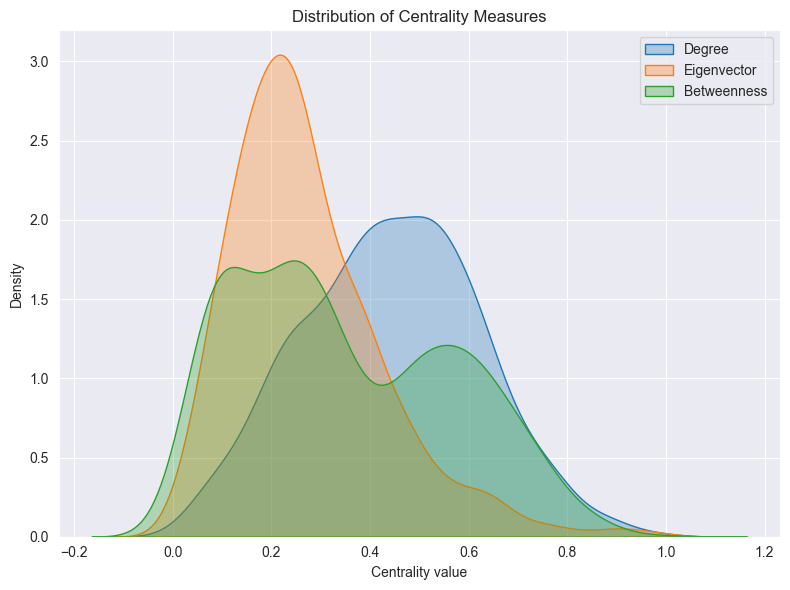

     Centrality  Node      Value
0        Degree   394  46.000000
1        Degree   352  44.000000
2        Degree   129  44.000000
3        Degree     5  42.000000
4        Degree   390  42.000000
5        Degree   197  42.000000
6        Degree   291  41.000000
7        Degree   236  41.000000
8        Degree   530  41.000000
9        Degree   285  41.000000
10  Eigenvector   394   0.073735
11  Eigenvector   352   0.067566
12  Eigenvector     5   0.064966
13  Eigenvector   285   0.064557
14  Eigenvector   146   0.064137
15  Eigenvector   323   0.063290
16  Eigenvector   129   0.063190
17  Eigenvector   291   0.062758
18  Eigenvector   197   0.062675
19  Eigenvector   390   0.062121
20  Betweenness   530   0.004928
21  Betweenness   129   0.004662
22  Betweenness     5   0.004517
23  Betweenness   352   0.004327
24  Betweenness   236   0.004239
25  Betweenness   570   0.004212
26  Betweenness   390   0.004085
27  Betweenness   334   0.004052
28  Betweenness   394   0.004004
29  Betwee

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, adjusted_rand_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from datetime import date

# Reproducibility
np.random.seed(123)
torch.manual_seed(123)

# Q4: Generate a Synthetic Network (Stochastic Block Model)

# Step 1: Hard-code the community sizes and connection probabilities

# Three communities (blocks)
block_sizes = [400, 350, 250]
num_blocks = len(block_sizes)
num_nodes = sum(block_sizes)

# SBM probability matrix:
# - Higher values on the diagonal mean stronger within-community ties
# - Lower off-diagonal values mean weaker between-community ties
P = np.array([
    [0.06, 0.01, 0.005],
    [0.01, 0.05, 0.008],
    [0.005, 0.008, 0.04]
])

# Step 2: Generate the graph with NetworkX
# networkx.stochastic_block_model returns an undirected graph by default
G = nx.stochastic_block_model(block_sizes, P, seed=123)
# edge list (u,v)
edge_list = pd.DataFrame(G.edges(), columns=["u", "v"])
print("\nEdge list (first 10 rows):")
print(edge_list.head(10))

# reconstruct the graph
G2 = nx.from_pandas_edgelist(edge_list, source="u", target="v")
print("\nReconstructed graph summary:")
print("  Nodes:", G2.number_of_nodes())
print("  Edges:", G2.number_of_edges())

# Compute three centrality
deg = dict(nx.degree(G2))
deg_value = np.array(list(deg.values()))
deg_summary = pd.Series(deg).describe()
print("\nDegree summary:")
print(deg_summary)

# Betweenness centrality
betw = nx.betweenness_centrality(G2, k=200, seed=123)
betw_values = np.array(list(betw.values()))

# eigenvector
eig = nx.eigenvector_centrality_numpy(G2)
eig_values = np.array(list(eig.values()))

# to plot in one figure -> standardize
scaler = StandardScaler()
deg_scaled = (deg_value - deg_value.min()) / (deg_value.max() - deg_value.min())
bwt_scaled = (betw_values - betw_values.min()) / (betw_values.max() - betw_values.min())
eig_scaled = (eig_values - eig_values.min()) / (eig_values.max() - eig_values.min())
import seaborn as sns

plt.figure(figsize=(8,6))

sns.kdeplot(deg_scaled, label="Degree", fill=True, alpha=0.3)
sns.kdeplot(bwt_scaled, label="Eigenvector", fill=True, alpha=0.3)
sns.kdeplot(eig_scaled, label="Betweenness", fill=True, alpha=0.3)

plt.title("Distribution of Centrality Measures")
plt.xlabel("Centrality value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# print top 10 nodes
# transform degree to dictionary
deg_dict  = dict(nx.degree(G2))
eig_dict  = nx.eigenvector_centrality(G2)
betw_dict = nx.betweenness_centrality(G2)

centralities = {
    "Degree":      deg_dict,
    "Eigenvector": eig_dict,
    "Betweenness": betw_dict,
}

rows = []
for name, centrality in centralities.items():
    top10 = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    for node, value in top10:
        rows.append({
            "Centrality": name,
            "Node":       node,
            "Value":      value
        })

df_top10 = pd.DataFrame(rows)
print(df_top10)

The top 10 nodes under each centrality measure are presented in the dataframe. While the three measures show considerable overlap — five nodes (394, 352, 129, 390, and 530) appear in the top 10 across all measures — degree and eigenvector centrality are most similar to each other, with the majority of their top-ranked nodes coinciding. Betweenness centrality, however, identifies several unique nodes not found in the other two rankings, including nodes 570, 179, and 334, suggesting these nodes play a distinct structural role as bridges within the network.


Community detection summary:
  Number of Louvain communities: 3
  Louvain community sizes (first 10): [400, 350, 250]

Adjusted Rand Index (Louvain vs truth): 1.0


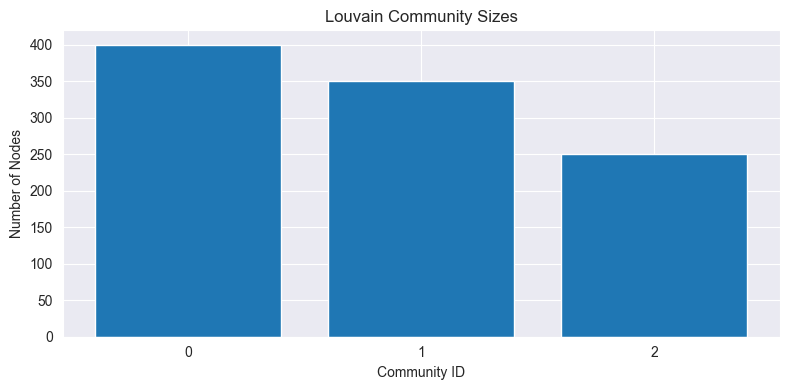

In [23]:
# Q5 community detection + evaluation
louvain_comms = nx.algorithms.community.louvain_communities(G2, seed=123)

# Convert communities into a node -> community_id vector
louvain_labels = np.zeros(num_nodes, dtype=int)

comm_id = 0
for comm in louvain_comms:
    for node in comm:
        louvain_labels[node] = comm_id
    comm_id = comm_id + 1

print("\nCommunity detection summary:")
print("  Number of Louvain communities:", len(louvain_comms))

louvain_sizes = [len(c) for c in louvain_comms]
print("  Louvain community sizes (first 10):", louvain_sizes[:10])

# Compare detected vs true communities (Adjusted Rand Index)
# ARI = 1 means perfect match; 0 means random-like agreement
# Step 3: Create ground-truth labels (community membership)

true_labels = np.concatenate([
    np.zeros(block_sizes[0], dtype=int),
    np.ones(block_sizes[1], dtype=int),
    2 * np.ones(block_sizes[2], dtype=int)
])

# Create synthetic node features correlated with communities
num_features = 8

centers = np.array([
    [2, 0, 0, 1, 0, 0, 1, 0],   # community 0 center
    [0, 2, 0, 0, 1, 0, 0, 1],   # community 1 center
    [0, 0, 2, 0, 0, 1, 1, 0]    # community 2 center
], dtype=float)

noise_sd = 0.8

X = np.zeros((num_nodes, num_features), dtype=float)
X[true_labels == 0] = centers[0] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 0), num_features))
X[true_labels == 1] = centers[1] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 1), num_features))
X[true_labels == 2] = centers[2] + np.random.normal(0, noise_sd, size=(np.sum(true_labels == 2), num_features))

# compare with ari
ari = adjusted_rand_score(true_labels, louvain_labels)
print("\nAdjusted Rand Index (Louvain vs truth):", ari)

# plot community result
plt.figure(figsize=(8, 4))
plt.bar(range(len(louvain_sizes)), louvain_sizes)
plt.xlabel("Community ID")
plt.ylabel("Number of Nodes")
plt.title("Louvain Community Sizes")
plt.xticks(range(len(louvain_sizes)))
plt.tight_layout()
plt.show()

There are 3 communities detected by Louvain, and the size of each community is 400, 350, and 250. ARI is 1 which means perfect match. This result is expected given that the data were generated from a Stochastic Block Model (SBM) with clearly separated blocks. One key reason community detection might fail even on SBM generated data is if the between-block and within-block edge probabilities are set too close to each other. When the signal-to-noise ratio is low, the block boundaries become ambiguous and Louvain may merge two weakly separated blocks into one or split a single block into multiple smaller communities."


Baseline (features-only) logistic regression:
  Validation accuracy: 0.965
  Test accuracy: 0.975

Adjacency matrix:
  Shape: (1000, 1000)
  Nonzeros: 23690
Epoch 1 | loss: 1.0389012098312378 | train_acc: 0.4266666769981384 | val_acc: 0.4699999988079071 | test_acc: 0.3700000047683716
Epoch 2 | loss: 1.0095269680023193 | train_acc: 0.4449999928474426 | val_acc: 0.47999998927116394 | test_acc: 0.4050000011920929
Epoch 3 | loss: 0.9788514971733093 | train_acc: 0.44333332777023315 | val_acc: 0.49000000953674316 | test_acc: 0.4000000059604645
Epoch 4 | loss: 0.9470292329788208 | train_acc: 0.4416666626930237 | val_acc: 0.47999998927116394 | test_acc: 0.39500001072883606
Epoch 5 | loss: 0.9143063426017761 | train_acc: 0.47999998927116394 | val_acc: 0.5400000214576721 | test_acc: 0.4449999928474426
Epoch 6 | loss: 0.8810445070266724 | train_acc: 0.6066666841506958 | val_acc: 0.6399999856948853 | test_acc: 0.5400000214576721
Epoch 7 | loss: 0.8476201891899109 | train_acc: 0.7183333039283752 |

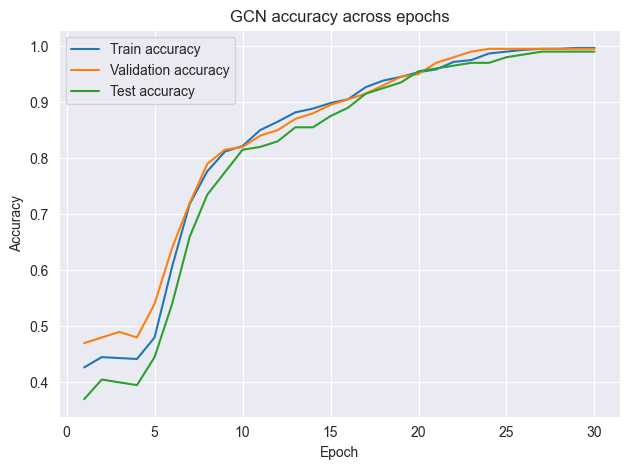

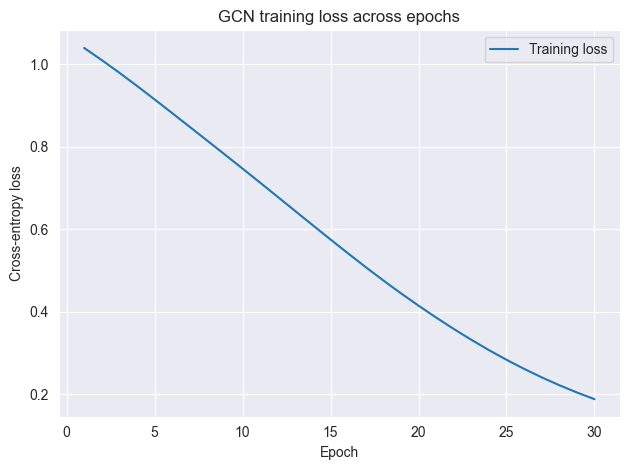


Model comparison:
  Baseline LR test accuracy: 0.975
  GCN test accuracy: 0.99

GCN confusion table (test set):
Predicted   0   1   2
True                 
0          87   0   0
1           0  60   0
2           1   1  51
Predicted   0   1   2
True                 
0          87   0   0
1           0  60   0
2           1   1  51


In [25]:
# Q6
# Split data into train, val, and test
# We do a simple random split of nodes.
perm = np.random.permutation(num_nodes)

train_size = int(0.60 * num_nodes)
val_size   = int(0.20 * num_nodes)
test_size  = num_nodes - train_size - val_size

train_idx = perm[:train_size]
val_idx   = perm[train_size:train_size + val_size]
test_idx  = perm[train_size + val_size:]

y = true_labels.copy()

#  Fit logistic regression on features only
lr = LogisticRegression(max_iter=200)
lr.fit(X[train_idx], y[train_idx])

yhat_val_lr  = lr.predict(X[val_idx])
yhat_test_lr = lr.predict(X[test_idx])

val_acc_lr  = accuracy_score(y[val_idx], yhat_val_lr)
test_acc_lr = accuracy_score(y[test_idx], yhat_test_lr)

print("\nBaseline (features-only) logistic regression:")
print("  Validation accuracy:", val_acc_lr)
print("  Test accuracy:", test_acc_lr)

# Convert the graph to a sparse adjacency matrix
A = nx.to_scipy_sparse_array(
    G2,
    nodelist=np.arange(num_nodes),
    format="csr",
    dtype=np.float32
)
print("\nAdjacency matrix:")
print("  Shape:", A.shape)
print("  Nonzeros:", A.nnz)

# Add self-loops and compute normalized adjacency (sparse)
I = sp.eye(num_nodes, format="csr", dtype=np.float32)
A_tilde = A + I

deg_tilde = np.array(A_tilde.sum(axis=1)).flatten()
deg_inv_sqrt = 1.0 / np.sqrt(deg_tilde)

D_inv_sqrt = sp.diags(deg_inv_sqrt.astype(np.float32), format="csr")
A_norm = D_inv_sqrt @ A_tilde @ D_inv_sqrt

# Step 2: Convert data to PyTorch tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

# Convert A_norm to a torch sparse tensor
A_norm_coo = A_norm.tocoo()
A_indices = torch.tensor(
    np.vstack((A_norm_coo.row, A_norm_coo.col)),
    dtype=torch.long
)
A_values = torch.tensor(A_norm_coo.data, dtype=torch.float32)
A_norm_t = torch.sparse_coo_tensor(A_indices, A_values, size=(num_nodes, num_nodes)).coalesce()

train_idx_t = torch.tensor(train_idx, dtype=torch.long)
val_idx_t   = torch.tensor(val_idx, dtype=torch.long)
test_idx_t  = torch.tensor(test_idx, dtype=torch.long)

# Define GCN parameters (two linear layers)
hidden_dim = 16
num_classes = num_blocks

lin1 = nn.Linear(num_features, hidden_dim)
lin2 = nn.Linear(hidden_dim, num_classes)

optimizer = torch.optim.Adam(list(lin1.parameters()) + list(lin2.parameters()), lr=0.01, weight_decay=5e-4)


# Step 4: Training loop (explicit; prints each epoch)
# 30 epochs to keep the output manageable in class.
epochs = 30

# Store training history so we can visualize performance across epochs
epoch_list = []
loss_history = []
train_acc_history = []
val_acc_history = []
test_acc_history = []

for epoch in range(1, epochs + 1):

    # Forward pass
    H0 = lin1(X_t)
    H1 = torch.sparse.mm(A_norm_t, H0)
    H1 = torch.relu(H1)

    Z0 = lin2(H1)
    logits = torch.sparse.mm(A_norm_t, Z0)

    # Loss on training nodes only
    loss = F.cross_entropy(logits[train_idx_t], y_t[train_idx_t])

    # Backprop + update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accuracy (train/val/test)
    preds = torch.argmax(logits, dim=1)

    train_acc = (preds[train_idx_t] == y_t[train_idx_t]).float().mean().item()
    val_acc   = (preds[val_idx_t]   == y_t[val_idx_t]).float().mean().item()
    test_acc  = (preds[test_idx_t]  == y_t[test_idx_t]).float().mean().item()

    print("Epoch", epoch, "| loss:", float(loss.detach().cpu().numpy()),
          "| train_acc:", train_acc, "| val_acc:", val_acc, "| test_acc:", test_acc)
    # Save values for plotting after training
    epoch_list.append(epoch)
    loss_history.append(float(loss.detach().cpu().numpy()))
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    test_acc_history.append(test_acc)

# -----------------------------------------------------------------------------
# Spaghetti-style training curves
# This shows how train / validation / test accuracy move across epochs.
# We also plot loss separately so students can compare optimization vs accuracy.

history_df = pd.DataFrame({
    "epoch": epoch_list,
    "loss": loss_history,
    "train_acc": train_acc_history,
    "val_acc": val_acc_history,
    "test_acc": test_acc_history
})

# Accuracy spaghetti plot
plt.figure()
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation accuracy")
plt.plot(history_df["epoch"], history_df["test_acc"], label="Test accuracy")
plt.title("GCN accuracy across epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Loss plot
plt.figure()
plt.plot(history_df["epoch"], history_df["loss"], label="Training loss")
plt.title("GCN training loss across epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion Matrix + Comparison
# Goal:
# - Compare baseline (feature-only LR) vs GCN (features + graph)
# - Show a confusion matrix-like table for the GCN test predictions

preds_np = preds.detach().cpu().numpy()

test_truth = y[test_idx]
test_pred_gcn = preds_np[test_idx]

test_acc_gcn = accuracy_score(test_truth, test_pred_gcn)

print("\nModel comparison:")
print("  Baseline LR test accuracy:", test_acc_lr)
print("  GCN test accuracy:", test_acc_gcn)

confusion_like = pd.crosstab(
    pd.Series(test_truth, name="True"),
    pd.Series(test_pred_gcn, name="Predicted")
)

print("\nGCN confusion table (test set):")
print(confusion_like)
print(confusion_like)

The GCN outperforms the baseline logistic regression (0.99 vs 0.975), suggesting that incorporating network structure through message passing provides additional predictive signal beyond node features alone. This result is expected in an SBM setting. The baseline logistic regression remains highly competitive at 0.975, which reflects the fact that the synthetic node features are already well-separated across communities. However, in real-world networks where node features are noisier and community boundaries are less clear, the GCN's ability to leverage both features and structure would likely produce a more substantial performance gap over a feature-only baseline.